In [1]:
import pandas as pd 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib
%matplotlib inline

In [2]:
df = pd.read_csv("Data/silent_sting_triage_data_sample.csv")

In [3]:
df

,Patient_ID,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
0,PAT_987231,43,Male,154,128,158,NaN,1,0,Black_Widow_Spider
1,PAT_079954,11,Female,138,154,108,Mild,0,0,Scorpion
2,PAT_567130,72,Female,211,105,112,Severe,0,1,Viper_Snake
3,PAT_500891,33,Female,173,79,121,Mild,0,0,Harmless_Insect
4,PAT_055399,79,Female,56,138,134,NaN,1,0,Black_Widow_Spider
...,...,...,...,...,...,...,...,...,...,...
499995,PAT_486699,15,Female,227,90,127,Mild,0,0,Harmless_Insect
499996,PAT_916404,52,Female,196,81,99,Mild,0,0,Harmless_Insect
499997,PAT_795752,55,Female,33,70,145,Mild,0,0,Harmless_Insect
499998,PAT_620887,58,Female,28,145,87,Medium,0,0,Viper_Snake


<h1>EDA</h1>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   Patient_ID                 500000 non-null  object
 1   Age                        500000 non-null  int64 
 2   Gender                     500000 non-null  object
 3   Time_Since_Bite_Min        500000 non-null  int64 
 4   Heart_Rate_BPM             500000 non-null  int64 
 5   Blood_Pressure_Systolic    500000 non-null  int64 
 6   Local_Swelling             424806 non-null  object
 7   Muscle_Paralysis_Present   500000 non-null  int64 
 8   Blood_Coagulation_Failure  500000 non-null  int64 
 9   Bite_Source_Target         500000 non-null  object
dtypes: int64(6), object(4)
memory usage: 38.1+ MB


In [5]:
df.describe()

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,44.511628,124.314880,105.002252,117.275516,0.143348,0.253102
std,23.076352,66.383475,27.055438,24.520117,0.350428,0.434789
min,5.000000,10.000000,40.000000,35.000000,0.000000,0.000000
25%,25.000000,67.000000,82.000000,99.000000,0.000000,0.000000
50%,45.000000,124.000000,102.000000,118.000000,0.000000,0.000000
75%,64.000000,182.000000,124.000000,133.000000,0.000000,1.000000
max,84.000000,239.000000,243.000000,223.000000,1.000000,1.000000


In [6]:
df = df.iloc[:,1:]

In [7]:
target = "Bite_Source_Target"

In [8]:
df[target].nunique()

4

In [9]:
df[target].value_counts()

Bite_Source_Target
Harmless_Insect       199982
Viper_Snake           149977
Black_Widow_Spider     75194
Scorpion               74847
Name: count, dtype: int64

In [10]:
summary = pd.DataFrame({
    "Count":[
        df.isna().sum().sum(), 
        df.duplicated().sum(), 
        df.select_dtypes(include=["object", "category"]).shape[1], 
        df.select_dtypes(include=np.number).shape[1], 
    ], 
    "Percent":[
        df.isna().sum().sum() / df.size * 100, 
        df.duplicated().sum() / df.size * 100, 
        df.select_dtypes(include=["object", "category"]).shape[1] / len(df.columns)* 100, 
        df.select_dtypes(include=np.number).shape[1] / len(df.columns) * 100, 
    ]
},
index=["Missing Values", "Duplicated Data", "Text Columns", "Numeric Columns"])

In [11]:
summary

,Count,Percent
Missing Values,75194,1.670978
Duplicated Data,715,0.015889
Text Columns,3,33.333333
Numeric Columns,6,66.666667


<h1>Visualization</h1>

In [12]:
target_percents = df[target].value_counts(normalize=True) * 100
target_percents

Bite_Source_Target
Harmless_Insect       39.9964
Viper_Snake           29.9954
Black_Widow_Spider    15.0388
Scorpion              14.9694
Name: proportion, dtype: float64

<BarContainer object of 4 artists>

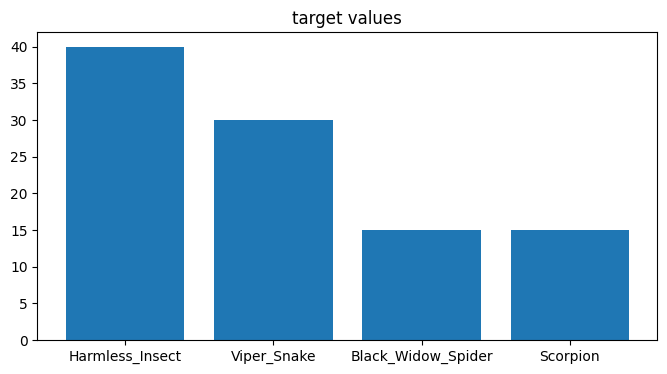

In [13]:
plt.figure(figsize=(8,4))
plt.title("target values")
plt.bar(target_percents.index, target_percents.values)

In [14]:
missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing

Local_Swelling               15.0388
Age                           0.0000
Gender                        0.0000
Heart_Rate_BPM                0.0000
Time_Since_Bite_Min           0.0000
Blood_Pressure_Systolic       0.0000
Muscle_Paralysis_Present      0.0000
Blood_Coagulation_Failure     0.0000
Bite_Source_Target            0.0000
dtype: float64

(0.0, 100.0)

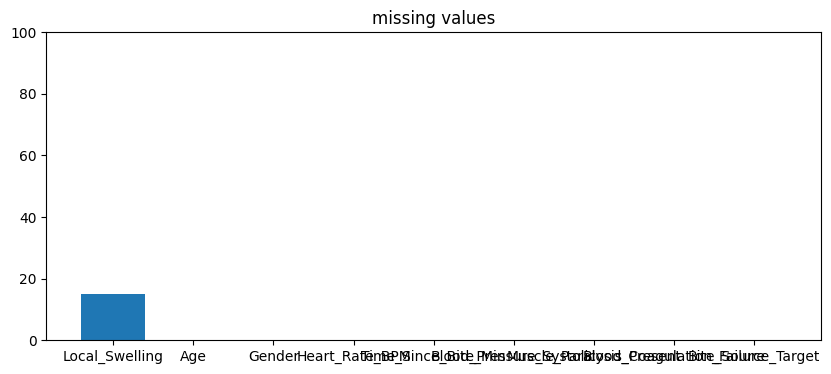

In [15]:
plt.figure(figsize=(10, 4))
plt.title("missing values")
plt.bar(missing.index, missing.values)
plt.ylim(0, 100)

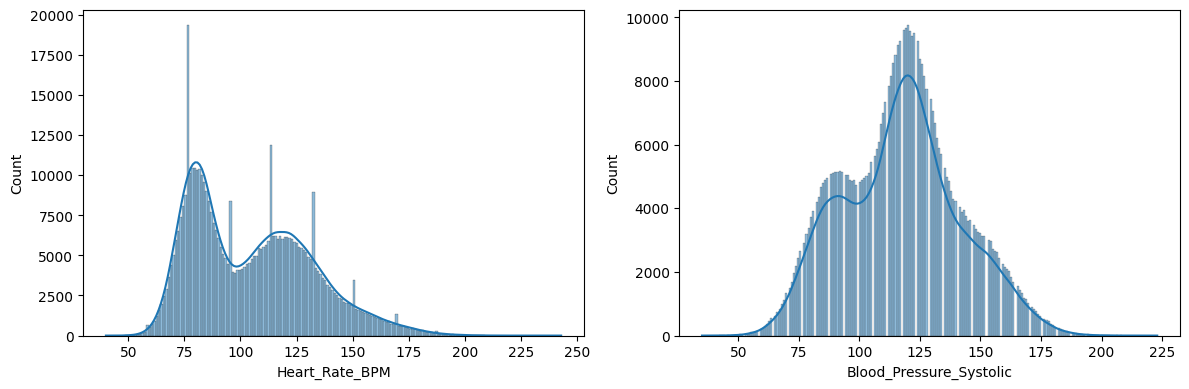

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for i , feature in enumerate(df.columns[[3,4]]):
    sns.histplot(
        data=df, 
        x=feature, 
        kde=True, 
        ax=axes[i]
    )
plt.tight_layout()

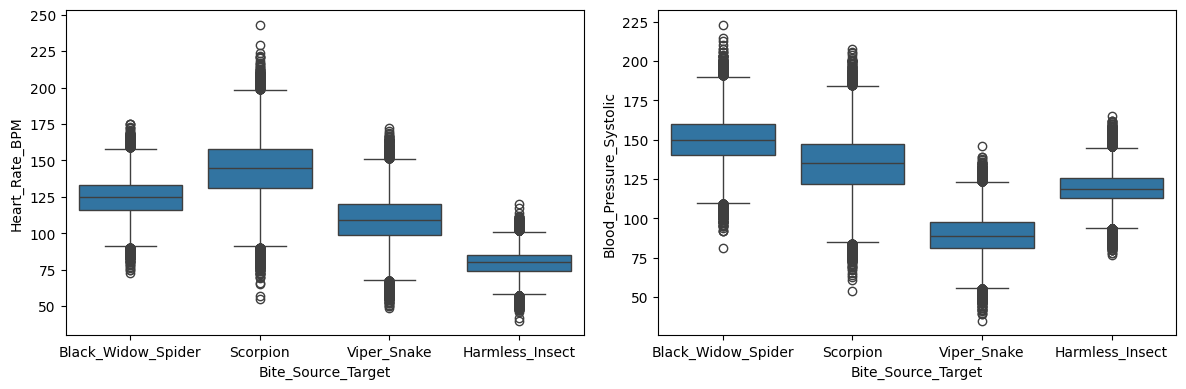

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for i , feature in enumerate(df.columns[[3,4]]):
    sns.boxplot(
        data=df, 
        x=target, 
        y=feature,
        ax=axes[i]
    )
plt.tight_layout()

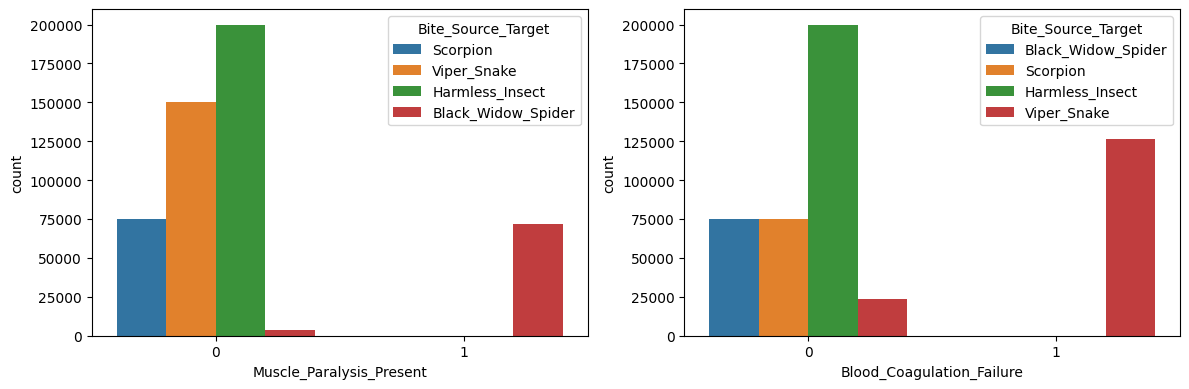

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for i , feature in enumerate(["Muscle_Paralysis_Present", "Blood_Coagulation_Failure"]):
    sns.countplot(
    data=df, 
    x=feature, 
    hue=target, 
    ax=axes[i]
)
plt.tight_layout()

In [19]:
# for having target in corr i make a copy of data frame 

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() 

df_corr = df.copy()
df_corr[target] = le.fit_transform(df_corr[target])

<Axes: >

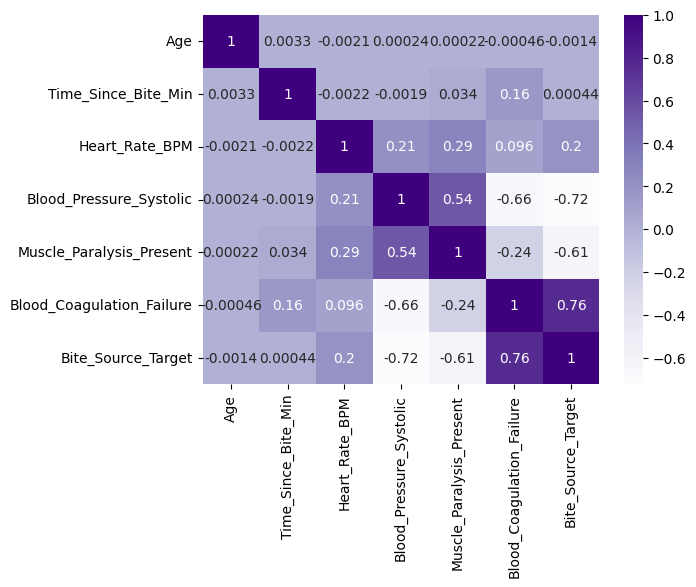

In [85]:
corr = df_corr.corr(numeric_only=True)
sns.heatmap(corr, cmap="Purples", annot=True)

In [21]:
corr

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
Age,1.000000,0.003305,-0.002067,0.000243,0.000215,-0.000455,-0.001448
Time_Since_Bite_Min,0.003305,1.000000,-0.002208,-0.001859,0.033636,0.158989,0.000439
Heart_Rate_BPM,-0.002067,-0.002208,1.000000,0.206661,0.294781,0.096246,0.196265
Blood_Pressure_Systolic,0.000243,-0.001859,0.206661,1.000000,0.539291,-0.660091,-0.723870
Muscle_Paralysis_Present,0.000215,0.033636,0.294781,0.539291,1.000000,-0.238128,-0.612474
Blood_Coagulation_Failure,-0.000455,0.158989,0.096246,-0.660091,-0.238128,1.000000,0.763443
Bite_Source_Target,-0.001448,0.000439,0.196265,-0.723870,-0.612474,0.763443,1.000000


<h1>Preprocessing</h1>

In [22]:
df[target].value_counts()

Bite_Source_Target
Harmless_Insect       199982
Viper_Snake           149977
Black_Widow_Spider     75194
Scorpion               74847
Name: count, dtype: int64

<h2>Remove Duplicates</h2>

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.isna().sum()

Age                              0
Gender                           0
Time_Since_Bite_Min              0
Heart_Rate_BPM                   0
Blood_Pressure_Systolic          0
Local_Swelling               75162
Muscle_Paralysis_Present         0
Blood_Coagulation_Failure        0
Bite_Source_Target               0
dtype: int64

<h2>Removing Outliers</h2>

In [25]:
def routliers(cols):
    df_clean = df.copy()

    for c in cols:
        q1 = df_clean[c].quantile(0.25)
        q3 = df_clean[c].quantile(0.75)
        iqr = q3 - q1 
        lower = q1 - 1.5 * iqr 
        upper = q3 +1.5 * iqr 

        df_clean = df_clean[
            (df_clean[c]>=lower)&
            (df_clean[c]<=upper)
        ]

    return df_clean 

In [26]:
remove_outlier_list = ["Time_Since_Bite_Min", "Heart_Rate_BPM", "Blood_Pressure_Systolic","Muscle_Paralysis_Present", "Blood_Coagulation_Failure"]
df = routliers(df[remove_outlier_list].columns)

In [27]:
df

,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
1,11,Female,138,154,108,Mild,0,0,Scorpion
2,72,Female,211,105,112,Severe,0,1,Viper_Snake
3,33,Female,173,79,121,Mild,0,0,Harmless_Insect
5,70,Male,90,137,85,Mild,0,0,Scorpion
6,68,Female,87,172,132,Mild,0,0,Scorpion
...,...,...,...,...,...,...,...,...,...
499995,15,Female,227,90,127,Mild,0,0,Harmless_Insect
499996,52,Female,196,81,99,Mild,0,0,Harmless_Insect
499997,55,Female,33,70,145,Mild,0,0,Harmless_Insect
499998,58,Female,28,145,87,Medium,0,0,Viper_Snake


In [28]:
df["Local_Swelling"] = df["Local_Swelling"].fillna("Unknown")

In [39]:
df = df.drop("Muscle_Paralysis_Present", axis=1)

<h1>Train Test Split</h1>

In [54]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
numeric_columns = df.select_dtypes(include=np.number).columns

In [55]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [56]:
y_train.value_counts()

Bite_Source_Target
Harmless_Insect       159543
Viper_Snake           119846
Scorpion               58808
Black_Widow_Spider      2795
Name: count, dtype: int64

<h1>Encoding & Scaling</h1>

In [57]:
X_train

,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Blood_Coagulation_Failure
263688,33,Female,22,123,86,Medium,0
222464,76,Female,188,76,116,Mild,0
491318,17,Male,183,71,122,Mild,0
281294,79,Male,121,117,144,Mild,0
467576,24,Female,168,79,127,Mild,0
...,...,...,...,...,...,...,...
219120,36,Male,150,86,93,Mild,0
111692,31,Male,42,117,104,Severe,0
136007,61,Other,124,77,137,Mild,0
222104,62,Male,123,80,116,Mild,0


In [58]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder

In [59]:
ct = ColumnTransformer(
    transformers=[
        (
            "OneHatEncoder",
            OneHotEncoder(), 
            [1,5]
        ), 
        (
            "Scaler",
            StandardScaler(), 
            numeric_columns
        )
    ], 
    remainder="passthrough"
)

In [60]:
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)
joblib.dump(ct, "pickles/column_transformer.pickle")

['pickles/column_transformer.pickle']

In [61]:
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  0.79358322,
        -1.20590773, -0.64901954],
       [ 1.        ,  0.        ,  0.        , ..., -0.94001827,
         0.19835298, -0.64901954],
       [ 0.        ,  1.        ,  0.        , ..., -1.12444397,
         0.47920512, -0.64901954],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.90313314,
         1.18133548, -0.64901954],
       [ 0.        ,  1.        ,  0.        , ..., -0.79247772,
         0.19835298, -0.64901954],
       [ 0.        ,  1.        ,  0.        , ..., -0.42362634,
        -0.08249916, -0.64901954]], shape=(340992, 12))

In [62]:
feature_names = ct.get_feature_names_out()
feature_names

array(['OneHatEncoder__Gender_Female', 'OneHatEncoder__Gender_Male',
       'OneHatEncoder__Gender_Other',
       'OneHatEncoder__Local_Swelling_Medium',
       'OneHatEncoder__Local_Swelling_Mild',
       'OneHatEncoder__Local_Swelling_Severe',
       'OneHatEncoder__Local_Swelling_Unknown', 'Scaler__Age',
       'Scaler__Time_Since_Bite_Min', 'Scaler__Heart_Rate_BPM',
       'Scaler__Blood_Pressure_Systolic',
       'Scaler__Blood_Coagulation_Failure'], dtype=object)

<h1>Mutal Info Classification</h1>

In [63]:
from sklearn.feature_selection import mutual_info_classif

mia = mutual_info_classif(X_train, y_train)
mia = pd.Series(mia)
mia

0     0.021050
1     0.021315
2     0.000446
3     0.034828
4     0.695749
5     0.541952
6     0.047013
7     0.000085
8     0.024283
9     0.675908
10    0.564363
11    0.479016
dtype: float64

<h1>Model</h1>

In [64]:
from sklearn.svm import SVC

In [65]:
classifier = SVC(kernel="linear")

In [66]:
classifier.fit(X_train, y_train)
joblib.dump(classifier, "pickles/classifier.pickle")

['pickles/classifier.pickle']

In [67]:
pre_test = classifier.predict(X_test)

In [69]:
pre_test

array(['Viper_Snake', 'Viper_Snake', 'Viper_Snake', ...,
       'Harmless_Insect', 'Viper_Snake', 'Viper_Snake'],
      shape=(85248,), dtype=object)

<h1>Cross Validation</h1>

In [70]:
from sklearn.model_selection import cross_val_score

In [71]:
cross_val = cross_val_score(
    estimator = classifier, 
    X = X_train, 
    y = y_train, 
    cv =5
)

In [72]:
cross_val.mean()*100

np.float64(99.63899449587548)

In [73]:
cross_val.std()*100

np.float64(0.021397456145048756)

<h1>Evaliuation</h1>

In [74]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [75]:
pre_test = classifier.predict(X_test)
pre_train = classifier.predict(X_train)

In [86]:
print("for train: ", accuracy_score(y_train, pre_train))
print("for test: ", accuracy_score(y_test, pre_test))

for train:  0.9963928772522522
for test:  0.9963166291291291


In [77]:
print(classification_report(y_test, pre_test))

                    precision    recall  f1-score   support

Black_Widow_Spider       1.00      1.00      1.00       688
   Harmless_Insect       0.99      1.00      1.00     39924
          Scorpion       1.00      0.98      0.99     14681
       Viper_Snake       1.00      1.00      1.00     29955

          accuracy                           1.00     85248
         macro avg       1.00      1.00      1.00     85248
      weighted avg       1.00      1.00      1.00     85248



<Axes: >

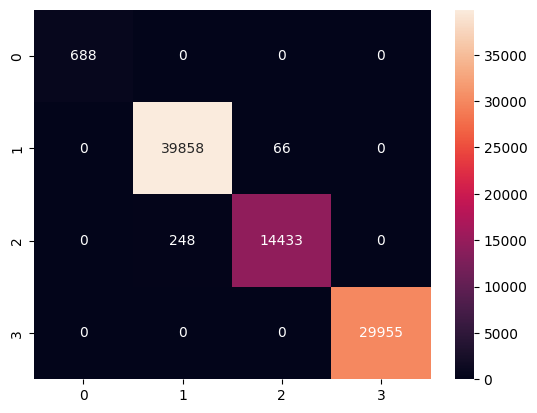

In [81]:
sns.heatmap(confusion_matrix(y_test, pre_test, ), annot=True, fmt="d")

In [87]:
len(y_test)

85248

<h1>Make PipeLine</h1>

In [82]:
from sklearn.pipeline import Pipeline 

pipeline = Pipeline([
    ("preprocessor", ct),
    ("model", classifier),
])

In [83]:
joblib.dump( pipeline, "pickles/pipeline.pickle")

['pickles/pipeline.pickle']